/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

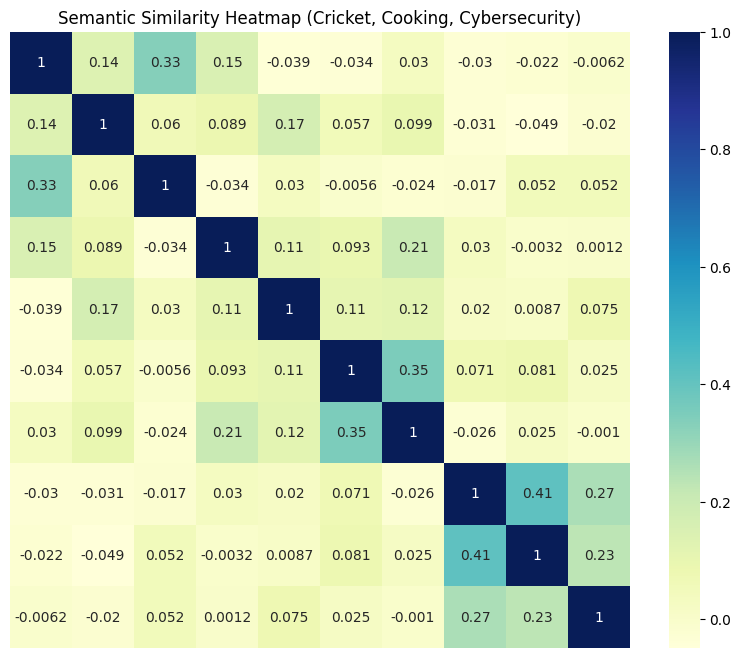


Query: The bowler took three wickets in one over
------------------------------
Similarity Score: 0.5387
Sentence: The batsman hit a magnificent six over the long-on boundary.

Similarity Score: 0.3004
Sentence: The test match ended in a thrilling draw after five days of play.



In [1]:
# !pip install sentence-transformers matplotlib seaborn

import torch
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialize Model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Define 10 sentences (3 topics: Cricket, Cooking, Cybersecurity)
sentences = [
    "The batsman hit a magnificent six over the long-on boundary.", # Cricket
    "Spinners often struggle to find grip on a dew-laden outfield.", # Cricket
    "The test match ended in a thrilling draw after five days of play.", # Cricket
    "Slow-cooking the brisket at a low temperature ensures maximum tenderness.", # Cooking
    "Always season your cast iron skillet after washing it to prevent rust.", # Cooking
    "A pinch of saffron can drastically change the aroma of the biryani.", # Cooking
    "Fresh herbs like cilantro and basil add a burst of flavor to any dish.", # Cooking
    "Multi-factor authentication is a critical defense against credential stuffing.", # Cybersecurity
    "Phishing attacks often use deceptive emails to steal sensitive user data.", # Cybersecurity
    "Zero-day vulnerabilities pose a significant risk to enterprise software security." # Cybersecurity
]

# 3. Generate Embeddings
embeddings = model.encode(sentences, convert_to_tensor=True)

# 4. Compute 10x10 Cosine Similarity Matrix
cosine_scores = util.cos_sim(embeddings, embeddings)

# 5. Display Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores.cpu().numpy(), annot=True, cmap='YlGnBu',
            xticklabels=False, yticklabels=False)
plt.title("Semantic Similarity Heatmap (Cricket, Cooking, Cybersecurity)")
plt.show()

# 6. Query Sentence Logic
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Find top 2 most similar
hits = util.semantic_search(query_embedding, embeddings, top_k=2)[0]

print(f"\nQuery: {query}")
print("-" * 30)
for hit in hits:
    print(f"Similarity Score: {hit['score']:.4f}")
    print(f"Sentence: {sentences[hit['corpus_id']]}\n")